In [1]:
import torch
import torch.nn as nn
import time
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import os
import math
import gc

from datasets import load_dataset
from transformers import AutoTokenizer
from torch.utils.data import DataLoader, IterableDataset

from architectures.gpt_wrapper import GPTWrapper
from architectures.mamba_wrapper import MambaWrapper
from architectures.flb_transformer import FLB_Transformer
from architectures.fam_wrapper import FAMTransformer
from architectures.xl_wrapper import XLWrapper

In [2]:
# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Settings
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
VOCAB_SIZE = 50257 # GPT-2 Default
HIDDEN_DIM = 256
SEQ_LEN = 128
BATCH_SIZE = 64
MAX_TOKENS = 105_000_000 # Stop training after 105M tokens for the full WikiText-103 run
DROPOUT = 0.1
AUX_WEIGHT = 0.05
LEARNING_RATE = 5e-4

torch.set_float32_matmul_precision('high')

# Data Structure for Benchmarking
results = {
    "model_name": [],
    "tokens_processed": [],
    "wall_clock_time": [],
    "loss_main": [],
    "loss_aux": []
}

#### Tokenize the entire dataset ahead of time

In [3]:
# # 1. Load and Tokenize EVERYTHING once
# tokenizer = AutoTokenizer.from_pretrained("gpt2")
# # Update the version tag to load the 103 million token dataset
# dataset = load_dataset("wikitext", "wikitext-103-v1", split="train")
# 
# print("Tokenizing entire dataset...")
# all_tokens = []
# for text in dataset['text']:
#     if text.strip():
#         all_tokens.extend(tokenizer.encode(text))
# 
# # 2. Save to your fast SSD
# torch.save(torch.tensor(all_tokens, dtype=torch.long), "wiki_tokens.pt")
# print(f"Saved {len(all_tokens)} tokens to wiki_tokens.pt")

In [4]:
def log_metric(model_name, tokens, start_time, loss_main, loss_aux):
    results["model_name"].append(model_name)
    results["tokens_processed"].append(tokens)
    results["wall_clock_time"].append(time.time() - start_time)
    results["loss_main"].append(loss_main)
    results["loss_aux"].append(loss_aux)

In [5]:
class LocalTokenDataset(torch.utils.data.Dataset):
    def __init__(self, file_path, seq_len=128):
        self.data = torch.load(file_path, weights_only=True)
        self.seq_len = seq_len
        
    def __len__(self):
        return (len(self.data) - 1) // self.seq_len
        
    def __getitem__(self, idx):
        i = idx * self.seq_len
        chunk = self.data[i : i + self.seq_len + 1]
        return chunk[:-1], chunk[1:]

# Update your loader
train_data = LocalTokenDataset("wiki_tokens.pt", seq_len=SEQ_LEN)
train_loader = torch.utils.data.DataLoader(
        train_data, 
        batch_size=BATCH_SIZE, 
        shuffle=True, 
        drop_last=True,
        num_workers=4,       # 1. Hires 4 background CPU threads to preload the next batches
        pin_memory=True,     # 2. Puts the data in a locked memory lane so the GPU can pull it instantly
        prefetch_factor=2    # 3. Tells each worker to always keep 2 batches ready to go
    )

In [6]:
def evaluate_model(model, model_name, loader):
    # Lock the model weights and turn off dropout
    model.eval()
    model.to(DEVICE)
    
    total_loss = 0.0
    total_batches = 0
    criterion = nn.CrossEntropyLoss()
    
    # Disable all gradient math to speed up the test and save memory
    with torch.no_grad():
        for x, y in tqdm(loader, desc=f"Evaluating {model_name}"):
            x = x.to(DEVICE)
            y = y.to(DEVICE)
            
            # Since you updated your wrappers, every model safely returns (logits, aux)
            logits, _ = model(x)
            
            loss = criterion(logits.view(-1, logits.size(-1)), y.view(-1))
            total_loss += loss.item()
            total_batches += 1
            
    avg_loss = total_loss / total_batches
    perplexity = math.exp(avg_loss)
    
    print(f"{model_name} Final Score | Loss: {avg_loss:.4f} | Perplexity: {perplexity:.2f}")
    return perplexity

In [7]:
def run_benchmark(model, model_name, loader, resume_checkpoint=None):
    # Standard sync and clear
    torch.cuda.synchronize()
    torch.cuda.empty_cache()

    # 1. Cast the ENTIRE architecture natively into BFloat16
    model.to(DEVICE, dtype=torch.bfloat16)

    print("compiling...")

    compiled_model = torch.compile(model, mode="reduce-overhead")
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss()
    # scaler = torch.amp.GradScaler('cuda', enabled=False)

    # Calculate how many batches make up 5 million tokens
    tokens_per_batch = BATCH_SIZE * SEQ_LEN
    MAX_BATCHES = MAX_TOKENS // tokens_per_batch
    
    start_time = time.time()
    tokens_count = 0
    current_batch = 0

    # If a checkpoint is provided we load the exact state of the entire training rig
    if resume_checkpoint:
        print(f"Loading checkpoint from {resume_checkpoint}...")
        checkpoint = torch.load(resume_checkpoint, weights_only=False)
        
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        # scaler.load_state_dict(checkpoint['scaler_state_dict'])
        
        current_batch = checkpoint['current_batch']
        tokens_count = checkpoint['tokens_count']
        print(f"Resumed successfully. Starting from batch {current_batch}.")
    
    # Track batches instead of tokens
    pbar = tqdm(total=MAX_BATCHES, initial=current_batch, desc=f"Training {model_name}")
    
    print("training...")

    # Keep restarting the dataset (new epochs) until we hit our total batch limit
    while current_batch < MAX_BATCHES:

        # 1. Turn the dataloader into a manual iterator
        loader_iter = iter(loader)

        # Calculate our exact local position inside the current epoch
        batches_to_skip = current_batch % len(loader)

        # 2. Fast-forward ONLY the leftover batches for this specific pass
        if batches_to_skip > 0:
            print(f"Fast-forwarding dataset by {batches_to_skip} batches. This may take a moment...")
            for _ in range(batches_to_skip):
                next(loader_iter)

        # 3. Read directly from the iterator instead of the raw loader
        for x, y in loader_iter:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            logits, aux = compiled_model(x)
            
            # Calculate the main text loss explicitly
            main_loss = criterion(logits.view(-1, logits.size(-1)), y.view(-1))
            
            # Combine them for the backward pass
            loss = main_loss + aux

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            # Grab both items for the log
            current_main = main_loss.item()
            current_aux = aux.item() if isinstance(aux, torch.Tensor) else aux
            tokens_count += x.numel()
            current_batch += 1

            # Pass both to our updated logger
            log_metric(model_name, tokens_count, start_time, current_main, current_aux)

            # Keep the progress bar showing the combined total
            pbar.set_postfix(main_loss=f"{(current_main):.4f}", aux_loss=f"{(current_aux):.4f}", total_loss=f"{(current_main + current_aux):.4f}")
            pbar.update(1) # Update by 1 batch

            # 4. Save a complete snapshot of the engine every 500 batches
            if current_batch % 500 == 0:
                checkpoint_path = f"models/{model_name}_checkpoint.pt"
                torch.save({
                    'current_batch': current_batch,
                    'tokens_count': tokens_count,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    # 'scaler_state_dict': scaler.state_dict()
                }, checkpoint_path)

            if current_batch >= MAX_BATCHES: break

    pbar.close()
    
    # Save the trained model weights to the models directory you created earlier
    model_save_path = f"models/{model_name}.pt"
    torch.save(model.state_dict(), model_save_path)
    print(f"Saved model weights to {model_save_path}")
    
    return results

In [8]:
# 1. FLB-Transformer
# flb = FLB_Transformer(vocab_size=VOCAB_SIZE, hidden_dim=HIDDEN_DIM, num_layers=6, seq_len=SEQ_LEN, batch_size=BATCH_SIZE)
# flb_results = run_benchmark(flb, "FLB-Transformer", train_loader)
# Load weights
# flb_results = run_benchmark(flb, "FLB-Transformer", train_loader, "models/FLB-Transformer_checkpoint.pt")

In [9]:
# Load and tokenize the holdout validation set
val_dataset = load_dataset("wikitext", "wikitext-103-v1", split="validation")
tokenizer = AutoTokenizer.from_pretrained("gpt2")
print("Tokenizing validation dataset...")
val_tokens = []
for text in val_dataset['text']:
    if text.strip():
        val_tokens.extend(tokenizer.encode(text))

torch.save(torch.tensor(val_tokens, dtype=torch.long), "wiki_val_tokens.pt")
print(f"Saved {len(val_tokens)} validation tokens.")

# Create the loader
val_data = LocalTokenDataset("wiki_val_tokens.pt", seq_len=SEQ_LEN)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)

/home/abrah/miniconda3/envs/flb-transformer/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Tokenizing validation dataset...
Saved 247137 validation tokens.


In [10]:
# The Gauntlet - Using lambdas to prevent all models from loading at once
baseline_configs = {
    # "FLB-Transformer": lambda: FLB_Transformer(vocab_size=VOCAB_SIZE, hidden_dim=HIDDEN_DIM, num_layers=6, seq_len=SEQ_LEN, batch_size=BATCH_SIZE),
    # "GPT-Baseline": lambda: GPTWrapper(VOCAB_SIZE, HIDDEN_DIM, num_layers=6, nhead=8, seq_len=SEQ_LEN),
    # "Mamba-SSM": lambda: MambaWrapper(VOCAB_SIZE, HIDDEN_DIM, num_layers=6),
    # "FAM-Baseline": lambda: FAMTransformer(VOCAB_SIZE, HIDDEN_DIM, num_layers=6, nhead=8),
    "XL-Baseline": lambda: XLWrapper(VOCAB_SIZE, HIDDEN_DIM, num_layers=6, nhead=8)
}

final_scores = {
    "FLB-Transformer": 88.90,
    "GPT-Baseline": 72.71
                }

# Force PyTorch to run in eager mode to save RAM
with torch._dynamo.config.patch(disable=True):
    for name, model_builder in baseline_configs.items():
        print(f"\n{'='*40}\nStarting {name}\n{'='*40}")
        
        model = model_builder()
        
        # Squeeze the memory hogs down to fit the RTX 3080
        if name == "Mamba-SSM":
            current_batch_size = 4
        elif name == "XL-Baseline":
            current_batch_size = 16  # Give XL some breathing room
        else:
            current_batch_size = BATCH_SIZE
        
        # Create temporary loaders using your existing datasets
        current_train_loader = torch.utils.data.DataLoader(
            train_loader.dataset, batch_size=current_batch_size, shuffle=False, drop_last=True
        )
        current_val_loader = torch.utils.data.DataLoader(
            val_loader.dataset, batch_size=current_batch_size, shuffle=False, drop_last=True
        )
        
        run_benchmark(model, name, current_train_loader)
        score = evaluate_model(model, name, current_val_loader)
        final_scores[name] = score
        
        print(f"Flushing {name} from memory...")
        del model
        del current_train_loader
        del current_val_loader
        gc.collect()
        torch.cuda.empty_cache()


Starting XL-Baseline
compiling...


Training XL-Baseline:   0%|          | 0/12817 [00:00<?, ?it/s]

training...
Saved model weights to models/XL-Baseline.pt


Evaluating XL-Baseline:   0%|          | 0/120 [00:00<?, ?it/s]

XL-Baseline Final Score | Loss: 4.8427 | Perplexity: 126.81
Flushing XL-Baseline from memory...


In [11]:
# Convert the global dictionary directly into a Pandas DataFrame
df = pd.DataFrame(results)

# Save the table to a CSV file so you can graph it later
csv_filename = "benchmark_results.csv"
df.to_csv(csv_filename, index=False)
print(f"Saved all training data to {csv_filename}")

# Display the last few rows to verify it worked
df.tail()

Saved all training data to benchmark_results.csv


,model_name,tokens_processed,wall_clock_time,loss_main,loss_aux
12812,XL-Baseline,26241024,3160.598911,5.46875,0.0
12813,XL-Baseline,26243072,3160.842105,5.37500,0.0
12814,XL-Baseline,26245120,3161.088566,5.21875,0.0
12815,XL-Baseline,26247168,3161.332968,5.15625,0.0
12816,XL-Baseline,26249216,3161.574687,5.81250,0.0


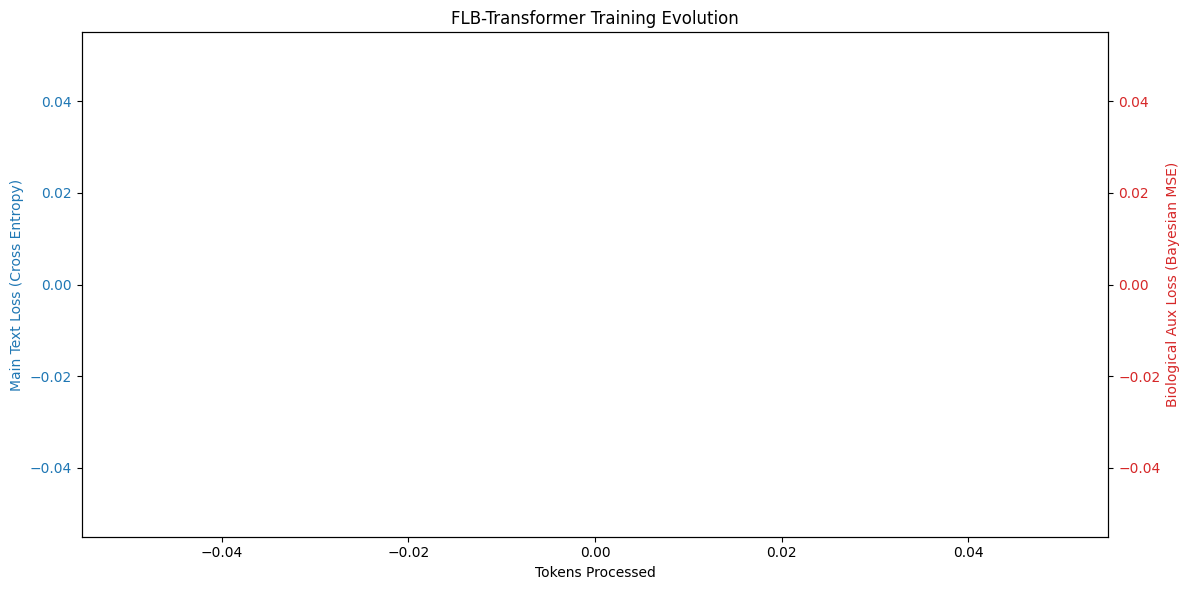

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_training_results(csv_file="benchmark_results.csv"):
    # Load the saved training data
    df = pd.read_csv(csv_file)
    
    # Filter for just our FLB-Transformer in case you run the baselines later
    df = df[df["model_name"] == "FLB-Transformer"]
    
    # Create a large canvas
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    # Plot the main text prediction loss on the left axis
    color1 = 'tab:blue'
    ax1.set_xlabel('Tokens Processed')
    ax1.set_ylabel('Main Text Loss (Cross Entropy)', color=color1)
    ax1.plot(df["tokens_processed"], df["loss_main"], color=color1, alpha=0.9, label="Text Prediction")
    ax1.tick_params(axis='y', labelcolor=color1)
    
    # Create a second y-axis that shares the same bottom x-axis
    ax2 = ax1.twinx()
    
    # Plot the biological auxiliary loss on the right axis
    color2 = 'tab:red'
    ax2.set_ylabel('Biological Aux Loss (Bayesian MSE)', color=color2)
    ax2.plot(df["tokens_processed"], df["loss_aux"], color=color2, alpha=0.6, label="Biological Memory")
    ax2.tick_params(axis='y', labelcolor=color2)
    
    plt.title('FLB-Transformer Training Evolution')
    fig.tight_layout()
    plt.show()

# Run this to generate the chart
plot_training_results()

In [13]:
perplexity = evaluate_model(flb, "FLB-Transformer", val_loader)

NameError: name 'flb' is not defined